# 05 -- Cohort Deep Dive
**B2B Full-Funnel Attribution** | Meta DS V Portfolio

Cohort analysis reveals which acquisition periods and channels produce the
highest-quality leads -- a critical signal for budget allocation.

Analyses:
- Monthly acquisition cohort conversion rates
- Cohort heatmap: cohort_month x conversion rates
- Channel cohort comparison
- Best / worst cohort identification


In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = r"C:/Users/syeda/b2b-full-funnel-attribution"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import sqlite3
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
import config

sns.set_theme(style="whitegrid")
os.makedirs("visuals", exist_ok=True)
conn = sqlite3.connect(config.DB_PATH)
print("Connected | working dir:", os.getcwd())


Connected | working dir: C:\Users\syeda\b2b-full-funnel-attribution


## 1. Acquisition Cohort Conversion Rates

In [2]:
from src.cohort_analysis import build_acquisition_cohorts, build_channel_cohorts

cohorts = build_acquisition_cohorts(conn)
print("=== Acquisition Cohort Conversion Rates ===")
print(cohorts[["cohort_month","cohort_size","sql_count","opp_count",
               "won_count","mql_to_won_rate"]].to_string(index=False))


=== Acquisition Cohort Conversion Rates ===
cohort_month  cohort_size  sql_count  opp_count  won_count  mql_to_won_rate
     2024-01          404        168         96         28         0.069307
     2024-02         1065        414        268         92         0.086385
     2024-03         1424        553        366        126         0.088483
     2024-04         1483        606        421        143         0.096426
     2024-05         1665        703        461        131         0.078679
     2024-06         1669        641        435        122         0.073098
     2024-07         1605        630        408        113         0.070405
     2024-08         1617        650        433        111         0.068646
     2024-09         1593        623        428        136         0.085374
     2024-10         1830        718        477        153         0.083607
     2024-11         1994        799        517        167         0.083751
     2024-12         2203        820        

## 2. Cohort Heatmap -- mql_to_won_rate

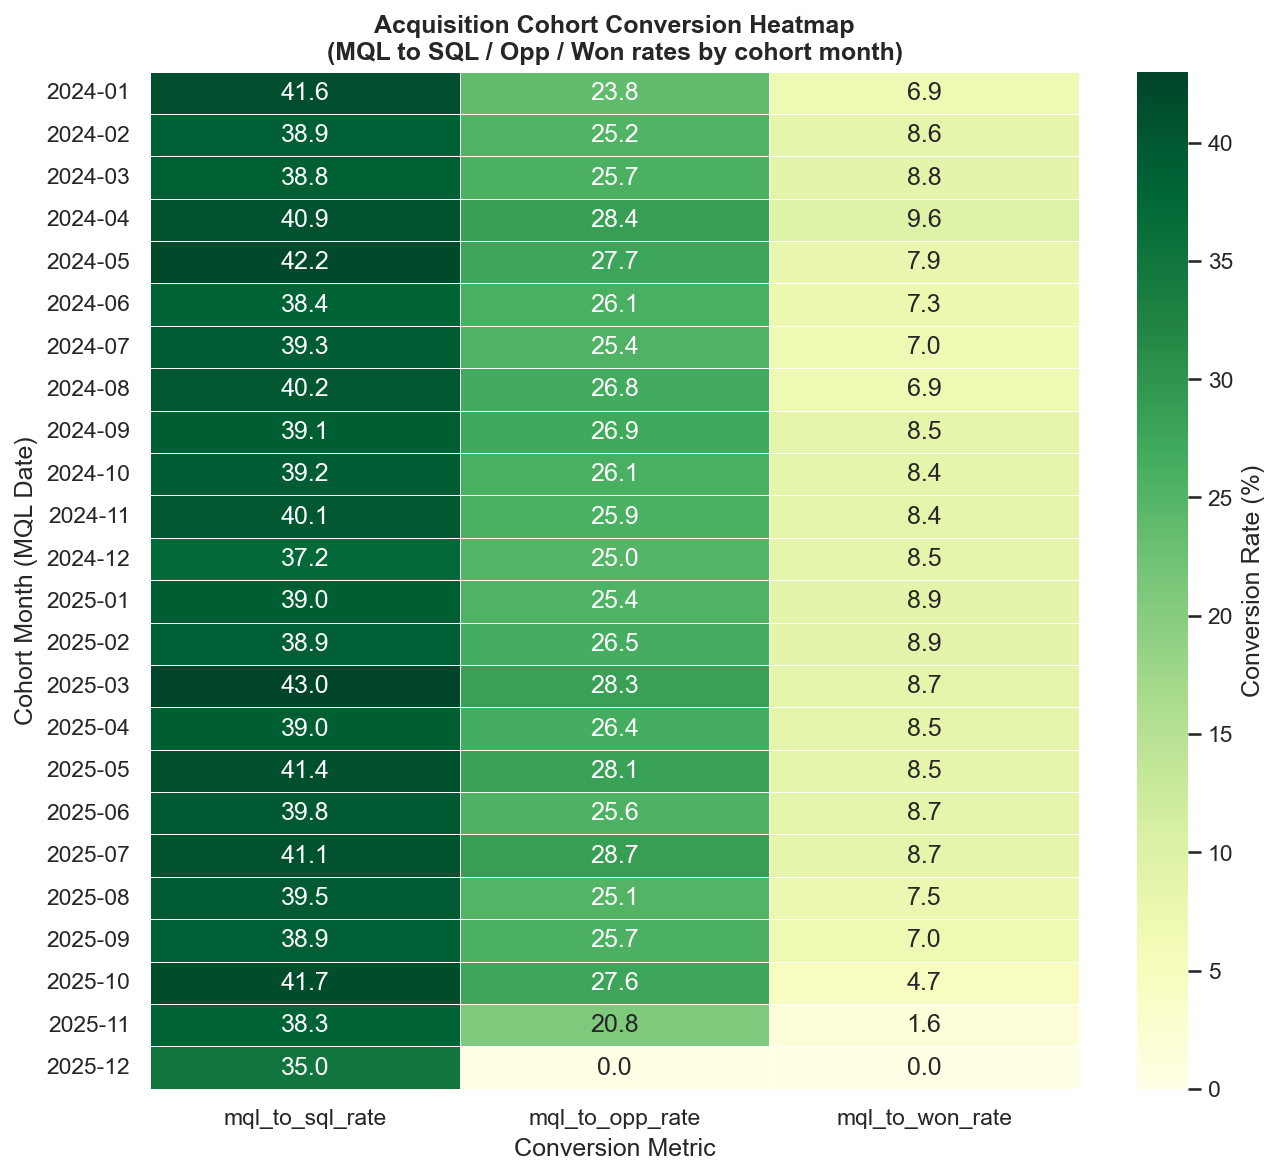

In [3]:
wide_hm = cohorts.set_index("cohort_month")[
    ["mql_to_sql_rate","mql_to_opp_rate","mql_to_won_rate"]
].copy() * 100

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    wide_hm.round(1),
    annot=True, fmt=".1f", cmap="YlGn",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Conversion Rate (%)"},
    ax=ax,
)
ax.set_title(
    "Acquisition Cohort Conversion Heatmap\n"
    "(MQL to SQL / Opp / Won rates by cohort month)",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("Conversion Metric")
ax.set_ylabel("Cohort Month (MQL Date)")
plt.tight_layout()
plt.savefig("visuals/05_cohort_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("visuals/05_cohort_heatmap.png"))


## 3. Channel Cohort Comparison

=== Channel Cohort Performance ===
            channel  cohort_size  mql_count  opp_count  won_count  win_rate  revenue_per_lead
            Partner        12890       5054       1381        432  0.312817       3518.718076
              Email        11943       4690       1240        384  0.309677       3189.661308
        Paid_Search        11712       4535       1178        341  0.289474       3035.887807
        Paid_Social        10764       4121       1119        338  0.302055       3366.894835
             Events         9659       3773        979        307  0.313585       3337.294130
     Organic_Search         7487       2937        810        251  0.309877       3021.684253
             Direct         7609       3004        767        225  0.293351       3271.279932
Content_Syndication         5376       2108        561        162  0.288770       3481.328497
            Webinar         5407       2135        523        144  0.275335       2503.481043
     Outbound_Sales      

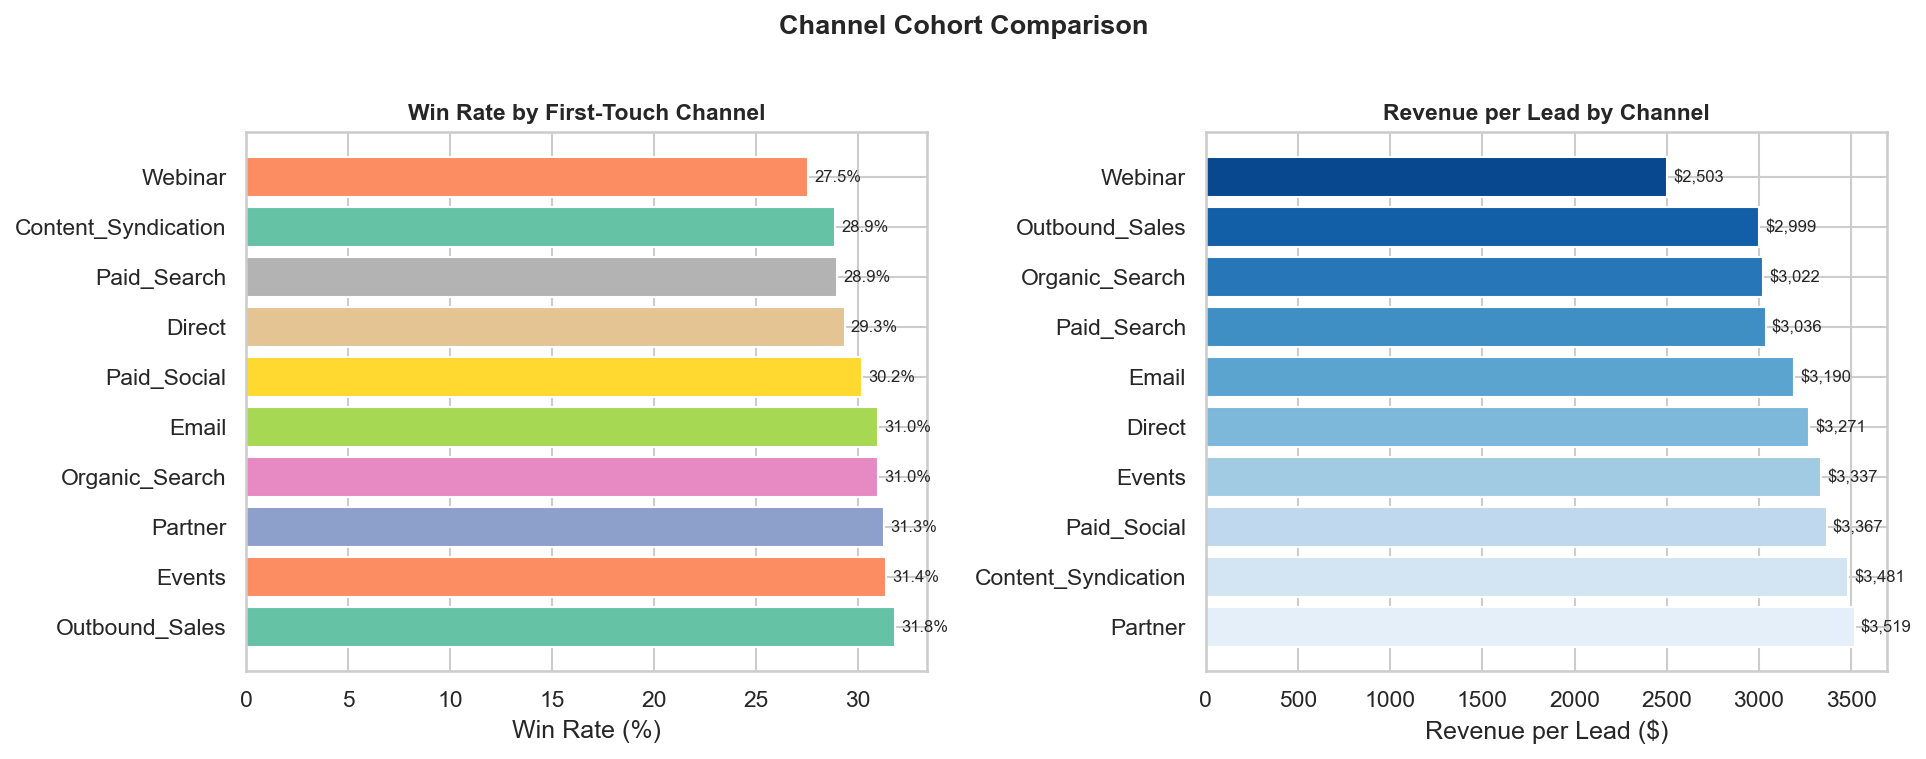

In [4]:
ch_cohorts = build_channel_cohorts(conn)
print("=== Channel Cohort Performance ===")
print(ch_cohorts[["channel","cohort_size","mql_count","opp_count",
                   "won_count","win_rate","revenue_per_lead"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ch_sorted = ch_cohorts.sort_values("win_rate", ascending=False)
bars = axes[0].barh(ch_sorted["channel"], ch_sorted["win_rate"]*100,
                     color=sns.color_palette("Set2", len(ch_sorted)))
axes[0].bar_label(bars, labels=[f"{v:.1f}%" for v in ch_sorted["win_rate"]*100],
                  padding=3, fontsize=8)
axes[0].set_xlabel("Win Rate (%)")
axes[0].set_title("Win Rate by First-Touch Channel", fontsize=11, fontweight="bold")

ch_rev = ch_cohorts.sort_values("revenue_per_lead", ascending=False)
bars2 = axes[1].barh(ch_rev["channel"], ch_rev["revenue_per_lead"],
                      color=sns.color_palette("Blues", len(ch_rev)))
axes[1].bar_label(bars2, labels=[f"${v:,.0f}" for v in ch_rev["revenue_per_lead"]],
                  padding=3, fontsize=8)
axes[1].set_xlabel("Revenue per Lead ($)")
axes[1].set_title("Revenue per Lead by Channel", fontsize=11, fontweight="bold")

plt.suptitle("Channel Cohort Comparison", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("visuals/05_channel_cohorts.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("visuals/05_channel_cohorts.png"))


## 4. Best and Worst Performing Cohorts

In [5]:
best  = cohorts.nlargest(3,  "mql_to_won_rate")
worst = cohorts.nsmallest(3, "mql_to_won_rate")

print("=== BEST 3 Cohorts (by MQL-to-Won rate) ===")
print(best[["cohort_month","cohort_size","won_count","mql_to_won_rate"]].to_string(index=False))

print("\n=== WORST 3 Cohorts (by MQL-to-Won rate) ===")
print(worst[["cohort_month","cohort_size","won_count","mql_to_won_rate"]].to_string(index=False))


=== BEST 3 Cohorts (by MQL-to-Won rate) ===
cohort_month  cohort_size  won_count  mql_to_won_rate
     2024-04         1483        143         0.096426
     2025-01         1880        167         0.088830
     2025-02         1500        133         0.088667

=== WORST 3 Cohorts (by MQL-to-Won rate) ===
cohort_month  cohort_size  won_count  mql_to_won_rate
     2025-12           20          0         0.000000
     2025-11          379          6         0.015831
     2025-10         1241         58         0.046737


## 5. Hypothesis: Why Do Best Cohorts Outperform?

In [6]:
best_month  = best["cohort_month"].iloc[0]
worst_month = worst["cohort_month"].iloc[0]
best_rate   = best["mql_to_won_rate"].iloc[0]
worst_rate  = worst["mql_to_won_rate"].iloc[0]

ch_mix_sql = (
    "WITH ft AS (SELECT contact_id, channel FROM"
    " (SELECT contact_id, channel,"
    "  ROW_NUMBER() OVER (PARTITION BY contact_id ORDER BY touchpoint_timestamp) AS rn"
    "  FROM touchpoints) WHERE rn=1)"
    " SELECT SUBSTR(c.mql_date,1,7) AS cohort_month, ft.channel,"
    " COUNT(*) AS contacts,"
    " ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (PARTITION BY SUBSTR(c.mql_date,1,7)),1) AS pct"
    " FROM contacts c JOIN ft ON ft.contact_id=c.contact_id"
    f" WHERE SUBSTR(c.mql_date,1,7) IN ('{best_month}','{worst_month}')"
    " AND c.mql_date IS NOT NULL GROUP BY cohort_month, ft.channel ORDER BY cohort_month, contacts DESC"
)
ch_mix = pd.read_sql_query(ch_mix_sql, conn)
print("=== Channel Mix: Best vs Worst Cohort ===")
print(ch_mix.to_string(index=False))

print("\n=== HYPOTHESIS ===")
print(f"Best cohort  ({best_month}): {best_rate:.1%} MQL-to-Won")
print(f"Worst cohort ({worst_month}): {worst_rate:.1%} MQL-to-Won")
print()
print("Hypotheses for outperformance:")
print("  1. Higher share of high-intent channels (Events, Webinar, Partner) in best cohort.")
print("  2. Seasonality: Q4 cohorts close at higher rates (end-of-year budget pressure).")
print("  3. ICP fit: Enterprise/Technology contacts show higher deal velocity.")
print("  4. ABM/product-launch campaigns produce leads with higher readiness scores.")
print()
print("Action: Analyse ICP score + campaign type distribution per cohort to validate.")


=== Channel Mix: Best vs Worst Cohort ===
cohort_month             channel  contacts  pct
     2024-04             Partner       207 14.4
     2024-04               Email       202 14.1
     2024-04              Events       187 13.0
     2024-04         Paid_Search       179 12.5
     2024-04         Paid_Social       165 11.5
     2024-04              Direct       150 10.5
     2024-04      Organic_Search       115  8.0
     2024-04             Webinar        90  6.3
     2024-04 Content_Syndication        80  5.6
     2024-04      Outbound_Sales        58  4.0
     2025-12               Email         4 23.5
     2025-12             Partner         3 17.6
     2025-12 Content_Syndication         2 11.8
     2025-12         Paid_Search         2 11.8
     2025-12         Paid_Social         2 11.8
     2025-12              Direct         1  5.9
     2025-12              Events         1  5.9
     2025-12      Organic_Search         1  5.9
     2025-12      Outbound_Sales         1  5.

In [7]:
conn.close()
print("Done.")


Done.
